# Deconvolution time constant (τ) per indicator

The suite2p spikes (`spks.npy`) were first deconvolved with the pipeline default τ = 0.7 s for every session, whatever the
indicator. In Oct 2026 they were re-deconvolved (`precompute_data/deconvolve_tau.py`) with
**τ = 1.1 s for the GCaMP6s mice (PZAG\*)** and **τ = 0.25 s for the GCaMP6f mice (PZAH\*)**, the decay time constants measured on
isolated calcium transients. This notebook documents that measurement.

**Method** (`tau_isolated_transients.py`, NEMO job 60042327; same procedure as the run of 4 Oct 2026 that set the values):

1. Trace: `Fstandard.npy` (neuropil-corrected F, the input of the deconvolution) of the concatenated suite2p dataset, cells only
   (`iscell`). Baseline: maximin (10-frame boxcar, min then max filter over 60 s), x = (F − baseline) / median(baseline).
2. Transients: peaks of x smoothed over 3 frames, above median + 6 robust SD (1.4826 MAD) and with a prominence above 4 SD.
   A transient is *isolated* if no other detected peak is within 4 s before or after it.
3. Cells with ≥ 5 isolated transients: median of the unsmoothed x from −0.5 to +4 s around the peaks (event-triggered average),
   fitted with a·exp(−t/τ) + c from one frame after the peak (τ bounded to 0.05–10 s; 0–2 % of cells at a bound).

τ was measured on the 5 multidepth sessions of the revision project. One session per mouse of the original project was added
to check that the values hold for the mice they were applied to.

Two other estimates were tried and discarded: an exponential fit of each transient from its peak (fits mostly at the bounds,
τ 0.05–0.7 s) and the decay of the trace autocovariance at lags ≥ 1 frame (2.5–4.9 s for GCaMP6s, inflated by slow
fluctuations).

**Choice.** One τ per indicator rather than one per session: for GCaMP6s, the mean of the three multidepth session medians
(0.96, 1.05, 1.32 s → 1.11 s), rounded to 1.1 s; for GCaMP6f, 0.25 s, the median of both multidepth sessions. The original-project
sessions measured afterwards (Oct 7) agree: 1.13 s for PZAG3.4f, 0.22–0.27 s for the six PZAH mice.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
COL = {"GCaMP6s": "#2a78d6", "GCaMP6f": "#eb6834"}
TAU_USED = {"GCaMP6s": 1.1, "GCaMP6f": 0.25}
TAU_DEFAULT = 0.7
MULTIDEPTH = ["PZAG17.3a_S20250319", "PZAG16.3c_S20250317", "PZAG16.3b_S20250317",
              "PZAH17.1e_S20250318", "PZAH17.1e_S20250313"]
plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "savefig.dpi": 120})

res = {}
for f in sorted((DATA / "isolated_transients").glob("*_tau.npz")):
    d = dict(np.load(f))
    res[str(d["session"])] = d
order = sorted(res, key=lambda s: (str(res[s]["indicator"]) == "GCaMP6f", s not in MULTIDEPTH, s))

## Decay time constant per session

In [ ]:
rows = []
for s in order:
    d = res[s]
    v = d["tau"][np.isfinite(d["tau"])]
    rows.append(dict(session=s, project="revisions (multidepth)" if s in MULTIDEPTH else "original",
                     indicator=str(d["indicator"]), cells=len(d["tau"]), fitted=len(v),
                     tau_median=np.median(v), q25=np.quantile(v, 0.25), q75=np.quantile(v, 0.75),
                     at_bounds=np.mean((v < 0.06) | (v > 9.9))))
table = pd.DataFrame(rows)
table.round(2)

,session,project,indicator,cells,fitted,tau_median,q25,q75,at_bounds
0,PZAG16.3b_S20250317,revisions (multidepth),GCaMP6s,655,478,1.32,1.11,1.67,0.01
1,PZAG16.3c_S20250317,revisions (multidepth),GCaMP6s,990,818,0.96,0.83,1.16,0.00
2,PZAG17.3a_S20250319,revisions (multidepth),GCaMP6s,660,409,1.05,0.87,1.24,0.02
3,PZAG3.4f_S20220419,original,GCaMP6s,1254,745,1.13,0.92,1.46,0.01
4,PZAH17.1e_S20250313,revisions (multidepth),GCaMP6f,703,180,0.25,0.18,0.35,0.02
5,PZAH17.1e_S20250318,revisions (multidepth),GCaMP6f,791,322,0.25,0.19,0.32,0.01
6,PZAH10.2d_S20230526,original,GCaMP6f,559,379,0.26,0.21,0.34,0.01
7,PZAH10.2f_S20230601,original,GCaMP6f,483,261,0.27,0.22,0.38,0.00
8,PZAH6.4b_S20220419,original,GCaMP6f,610,340,0.22,0.17,0.27,0.01
9,PZAH8.2f_S20230109,original,GCaMP6f,655,249,0.26,0.21,0.34,0.01


In [ ]:
summary = table.groupby(["indicator", "project"]).tau_median.agg(["count", "median", "min", "max"])
print(summary.round(2))
for ind, used in TAU_USED.items():
    m = table[table.indicator == ind].tau_median
    print(f"{ind}: session medians {m.min():.2f}-{m.max():.2f} s (mean {m.mean():.2f} s) -> tau used {used} s")

                                  count  median   min   max
indicator project                                          
GCaMP6f   original                    6    0.26  0.22  0.27
          revisions (multidepth)      2    0.25  0.25  0.25
GCaMP6s   original                    1    1.13  1.13  1.13
          revisions (multidepth)      3    1.05  0.96  1.32
GCaMP6s: session medians 0.96-1.32 s (mean 1.12 s) -> tau used 1.1 s
GCaMP6f: session medians 0.22-0.27 s (mean 0.25 s) -> tau used 0.25 s


## Isolated transients: examples

Example cells are the three cells closest to the session's median τ (≥ 10 isolated events). Left: 2 min of x with the isolated
transients marked. Right: event-triggered average of each cell (median over its isolated transients) and the exponential fit.

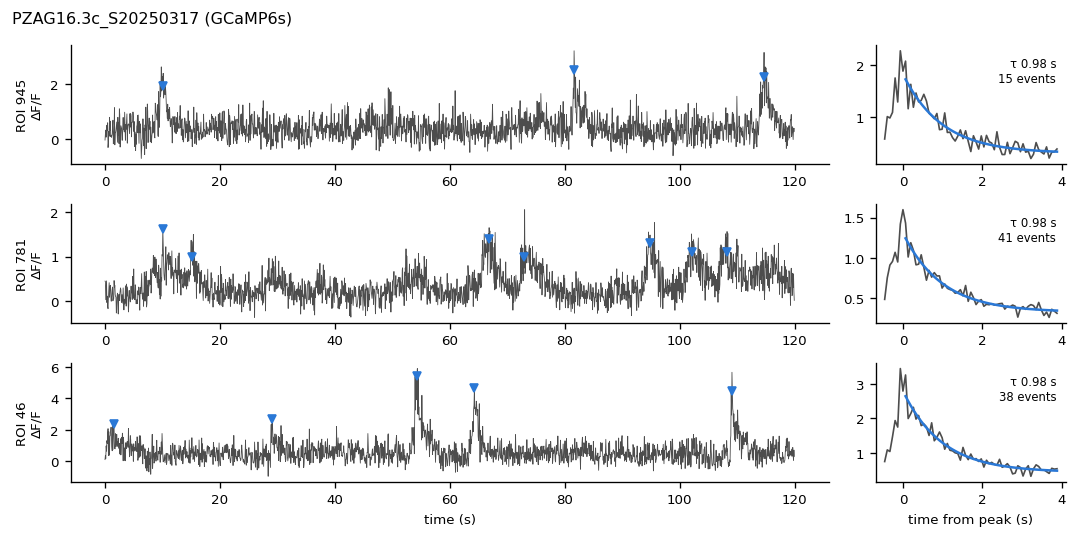

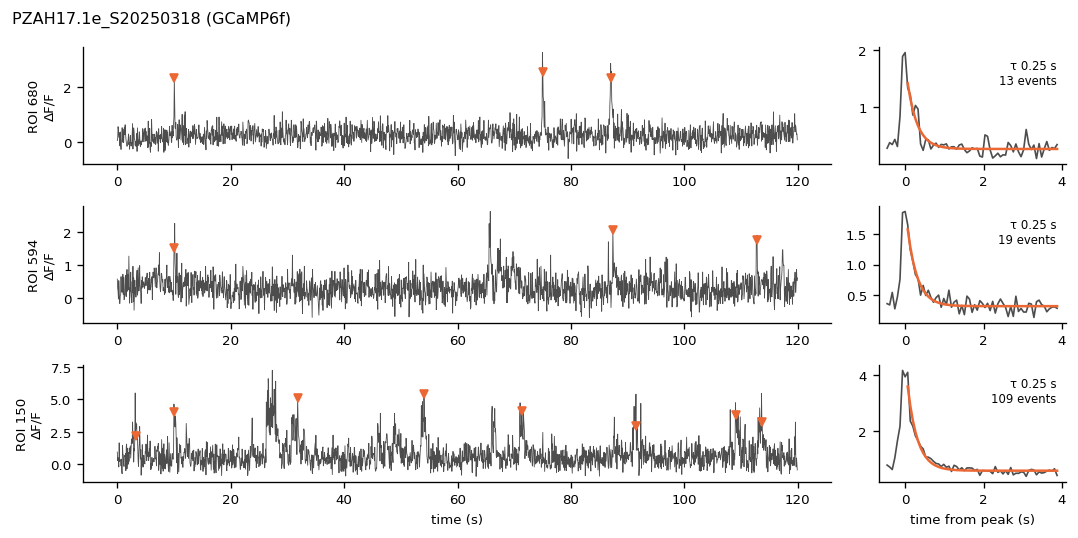

In [ ]:
def example_figure(session):
    d = res[session]
    fs, ind = float(d["fs"]), str(d["indicator"])
    fig, axs = plt.subplots(3, 2, figsize=(9, 4.5), gridspec_kw=dict(width_ratios=[4, 1]))
    for k, roi in enumerate(d["example_roi"]):
        i = np.flatnonzero((d["roi"] == roi) & (d["plane"] == d["example_plane"]))[0]
        tr = d["example_trace"][k]
        ev = d["example_events"][k]
        ev = ev[ev >= 0]
        t = np.arange(len(tr)) / fs
        axs[k, 0].plot(t, tr, c="0.3", lw=0.5)
        axs[k, 0].plot(t[ev], tr[ev], "v", c=COL[ind], ms=5)
        axs[k, 0].set_ylabel(f"ROI {roi}\nΔF/F")
        t_eta = d["eta_t"]
        axs[k, 1].plot(t_eta, d["eta"][i], c="0.3", lw=1)
        tf = t_eta[t_eta > 0]
        axs[k, 1].plot(tf, d["amp"][i] * np.exp(-tf / d["tau"][i]) + d["offset"][i], c=COL[ind], lw=1.5)
        axs[k, 1].text(0.95, 0.9, f"τ {d['tau'][i]:.2f} s\n{d['n_events'][i]} events", transform=axs[k, 1].transAxes,
                       ha="right", va="top", fontsize=7)
    axs[-1, 0].set_xlabel("time (s)")
    axs[-1, 1].set_xlabel("time from peak (s)")
    fig.suptitle(f"{session} ({ind})", x=0.01, ha="left")
    fig.tight_layout()
    return fig

example_figure("PZAG16.3c_S20250317");
example_figure("PZAH17.1e_S20250318");

## Distributions and average decay

Left: per-cell τ for each session (box: quartiles, whiskers: 1.5 IQR), with the default 0.7 s (grey dotted) and the value used
for each indicator (coloured dashed). Right: event-triggered averages normalised to their fitted amplitude, median over cells
of all sessions of each indicator, with exp(−t/τ) for the τ used.

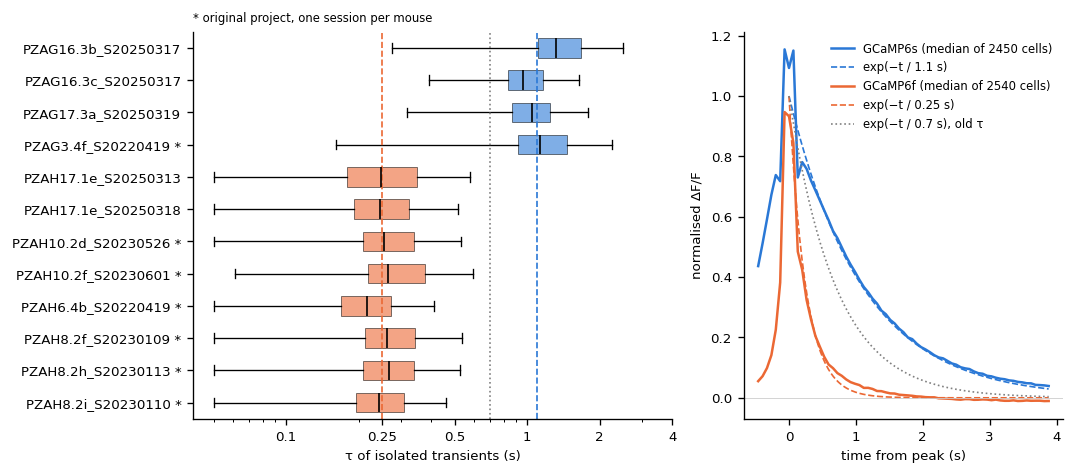

In [ ]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw=dict(width_ratios=[3, 2]))
for y, s in enumerate(order):
    d = res[s]
    v = d["tau"][np.isfinite(d["tau"])]
    ind = str(d["indicator"])
    bp = ax.boxplot(v, positions=[y], vert=False, widths=0.6, showfliers=False, patch_artist=True,
                    medianprops=dict(color="k"), boxprops=dict(facecolor=COL[ind], alpha=0.6, lw=0.5),
                    whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8))
ax.set_yticks(range(len(order)), [s + ("" if s in MULTIDEPTH else " *") for s in order])
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4], ["0.1", "0.25", "0.5", "1", "2", "4"])
ax.axvline(TAU_DEFAULT, c="0.5", ls=":", lw=1)
for ind, used in TAU_USED.items():
    ax.axvline(used, c=COL[ind], ls="--", lw=1)
ax.set_xlabel("τ of isolated transients (s)")
ax.set_title("* original project, one session per mouse", fontsize=7, loc="left")

for ind in COL:
    etas = []
    for s in order:
        d = res[s]
        if str(d["indicator"]) != ind:
            continue
        ok = np.isfinite(d["tau"])
        etas.append((d["eta"][ok] - d["offset"][ok, None]) / d["amp"][ok, None])
        t_eta = d["eta_t"]
    eta = np.median(np.concatenate(etas), axis=0)
    ax2.plot(t_eta, eta, c=COL[ind], lw=1.5, label=f"{ind} (median of {sum(map(len, etas))} cells)")
    tf = np.linspace(0, t_eta[-1], 200)
    ax2.plot(tf, np.exp(-tf / TAU_USED[ind]), c=COL[ind], ls="--", lw=1, label=f"exp(−t / {TAU_USED[ind]} s)")
ax2.plot(tf, np.exp(-tf / TAU_DEFAULT), c="0.5", ls=":", lw=1, label=f"exp(−t / {TAU_DEFAULT} s), old τ")
ax2.axhline(0, c="0.8", lw=0.5)
ax2.set_xlabel("time from peak (s)")
ax2.set_ylabel("normalised ΔF/F")
ax2.legend(frameon=False, fontsize=7)
fig.tight_layout()

## Caveats

- Large isolated transients are often bursts, which decay slightly more slowly than single spikes: τ may be slightly
  overestimated.
- The fit starts one frame (66 ms) after the peak and ignores the rise; OASIS models an AR(1) decay only, as in the pipeline.
- **Pipeline reruns** must pass these values (`--tau 1.1` for PZAG mice, `--tau 0.25` for PZAH mice), or they will bring back
  τ = 0.7 s spikes. The old spikes are backed up in the NEMO run directory (`backups/spks_tau0.7/`), and the flexilims `tau`
  attribute of the re-deconvolved datasets is set.

**Reproduce:** on NEMO, from the run directory with `src/` synced, write a manifest of `SESSION [--project PROJECT]` lines and run
`sbatch --array=0-N tau_isolated_transients.sbatch MANIFEST OUT_DIR`, then copy `OUT_DIR/*_tau.npz` to
`data/isolated_transients/`.